In [1]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import plotly.express as px
import geopandas as gpd
import plotly.graph_objects as go
from shapely.geometry import mapping
from shapely.geometry import Point

In [2]:
tract_shp = "data_raw/tl_2022_37_tract" 

out_path = "selected_outlier_tracts_map.png"

tract_geo = gpd.read_file(tract_shp)
# make sure it's in WGS84 for plotting
tract_geo = tract_geo.to_crs(epsg=4326)

Saved map to data_processed/nc_outliers_map.png
Saved outlier tracts to data_processed/nc_outlier_tracts.geojson


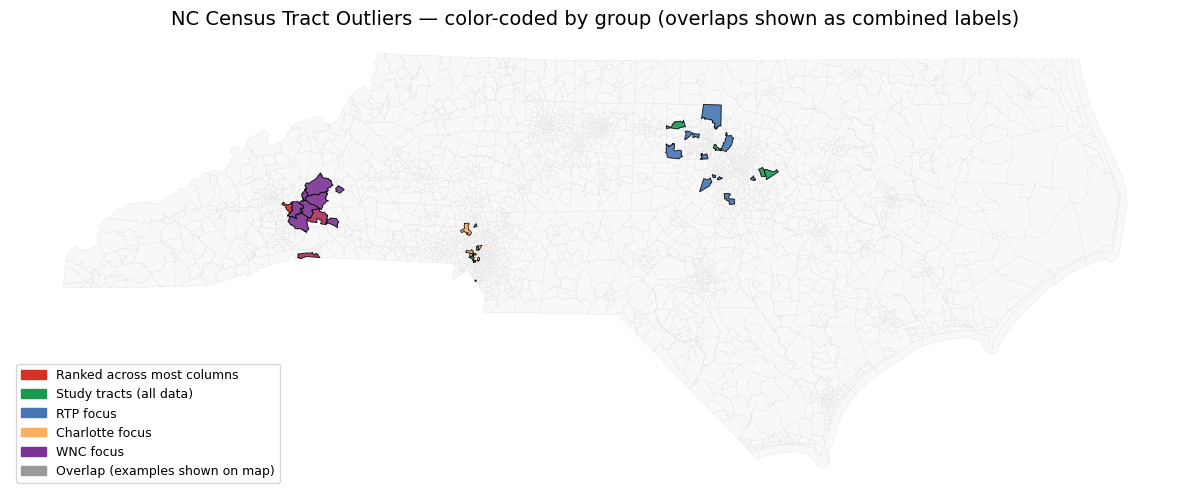

In [3]:
# Ensure GEOID exists and is string
tract_geo["GEOID"] = tract_geo["GEOID"].astype(str)

# ---- define your groups (from your lists) ----
ranked_most = [
    "37149920304",
    "37021003203",
    "37161960301"
]

study_tracts = [
    "37183054402",
    "37135011103",
    "37063001809",
    "37119003802",
    "37183054108",
    "37119006212"
]

rtp_focus = [
    "37063001900",
    "37183053109",
    "37063002100",
    "37183053430",
    "37183052810",
    "37135011210",
    "37135010902",
    "37063002020",
    "37183053428",
    "37183053419"
]

charlotte_focus = [
    "37119006212",
    "37119002702",
    "37119003902",
    "37119004000",
    "37119003600",
    "37119005856",
    "37119003110",
    "37119004800",
    "37119006222",
    "37119005100"
]

wnc_focus = [
    "37149920304",
    "37111970700",
    "37111970800",
    "37021003204",
    "37111970500",
    "37021003205",
    "37089930100",
    "37021003105",
    "37161960301",
    "37161960202"
]

# Put into a dict for convenience and plotting order
groups = {
    "Ranked across most columns": ranked_most,
    "Study tracts (all data)": study_tracts,
    "RTP focus": rtp_focus,
    "Charlotte focus": charlotte_focus,
    "WNC focus": wnc_focus
}

# ---- Attach boolean flags for each group ----
for name, geoids in groups.items():
    col = name.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("-", "_")
    tract_geo[col] = tract_geo["GEOID"].isin(geoids)

# ---- create a combined label (for overlaps) ----
def combined_label(row):
    present = [name for name in groups.keys() if row[name.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("-", "_")]]
    if not present:
        return "Other"
    if len(present) == 1:
        return present[0]
    # If multiple, produce a short combined label
    return " & ".join(present)

# Make a clean mapping from column names to group keys used in combined_label
# We'll compute combined_label by checking the boolean columns we created
bool_cols = [name.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("-", "_") for name in groups.keys()]

def combined_label_from_boolcols(r):
    present = [orig_name for orig_name, col in zip(groups.keys(), bool_cols) if r[col]]
    if not present:
        return "Other"
    if len(present) == 1:
        return present[0]
    return " & ".join(present)

tract_geo["plot_label"] = tract_geo.apply(combined_label_from_boolcols, axis=1)

# ---- Create a palette for unique combinations ----
unique_labels = tract_geo["plot_label"].unique().tolist()

# Choose colors for primary single groups first, then generate distinguishable colors for combinations.
base_colors = {
    "Ranked across most columns": "#d73027",   # red
    "Study tracts (all data)": "#1a9850",      # green
    "RTP focus": "#4575b4",                    # blue
    "Charlotte focus": "#fdae61",              # orange
    "WNC focus": "#7b3294"                     # purple
}

# Build color map: single-group labels get base color; combined labels get blended color or a gray
color_map = {}
for label in unique_labels:
    if label in base_colors:
        color_map[label] = base_colors[label]
    elif label == "Other":
        color_map[label] = "#f0f0f0"  # background light gray
    else:
        # For combined labels, create a blended color by averaging the RGBs of the member groups
        parts = [p.strip() for p in label.split("&")]
        parts = [p.strip() for p in label.split("&")]  # e.g., ["RTP focus", "Charlotte focus"]
        # match names in groups keys (they are exact)
        # gather base colors where available
        rgbs = []
        for p in parts:
            p = p.strip()
            if p in base_colors:
                hexc = base_colors[p]
                hexc = hexc.lstrip("#")
                rgbs.append(tuple(int(hexc[i:i+2], 16) for i in (0, 2, 4)))
        if rgbs:
            avg = tuple(int(sum(c[i] for c in rgbs)/len(rgbs)) for i in range(3))
            color_map[label] = "#{:02x}{:02x}{:02x}".format(*avg)
        else:
            color_map[label] = "#999999"

# ---- Plotting ----
fig, ax = plt.subplots(figsize=(12, 12))
# Plot base (all tracts) in very light gray
tract_geo.plot(ax=ax, color="#f8f8f8", edgecolor="#dcdcdc", linewidth=0.2)

# Plot each label in order so single groups are visible; ensure 'Other' is at bottom
plot_order = sorted(unique_labels, key=lambda s: (s != "Other", len(s)))  # 'Other' first
for label in plot_order:
    subset = tract_geo[tract_geo["plot_label"] == label]
    if len(subset) == 0 or label == "Other":
        continue
    subset.plot(ax=ax, color=color_map[label], edgecolor="black", linewidth=0.6, alpha=0.9)

# Make 'Other' thin boundary (optional)
# tract_geo[tract_geo["plot_label"] == "Other"].boundary.plot(ax=ax, linewidth=0.2, color="#dcdcdc")

ax.set_title("NC Census Tract Outliers — color-coded by group (overlaps shown as combined labels)", fontsize=14)
ax.axis("off")

# ---- Legend ----
# Create patches for main single groups first
legend_patches = []
# keep legend order same as groups dict
for k in groups.keys():
    legend_patches.append(mpatches.Patch(color=color_map[k], label=k))
# Add a patch for overlaps if any
overlap_labels = [lbl for lbl in unique_labels if (" & " in lbl)]
if overlap_labels:
    # include one example patch for overlaps
    legend_patches.append(mpatches.Patch(color="#999999", label="Overlap (examples shown on map)"))

ax.legend(handles=legend_patches, loc="lower left", fontsize=9, frameon=True)

# ---- Save figure ----
plt.tight_layout()
out_png = "data_processed/nc_outliers_map.png"
fig.savefig(out_png, dpi=300)
print(f"Saved map to {out_png}")

# ---- Optional: export only the outlier tracts to GeoJSON for interactive viewing ----
outliers = tract_geo[tract_geo["plot_label"] != "Other"].copy()
# ensure a friendly attribute for popup/viewers
outliers["label_short"] = outliers["plot_label"]
out_geojson = "data_processed/nc_outlier_tracts.geojson"
outliers.to_file(out_geojson, driver="GeoJSON")
print(f"Saved outlier tracts to {out_geojson}")

plt.show()

In [4]:
bool_cols = []
for name, geoids in groups.items():
    col = name
    if col not in tract_geo.columns:
        tract_geo[col] = tract_geo["GEOID"].isin(geoids)
    bool_cols.append(col)

def combined_label_from_boolcols(row):
    present = [orig_name for orig_name in bool_cols if row[orig_name]]
    if not present:
        return "Other"
    if len(present) == 1:
        return present[0]
    return " & ".join(present)

tract_geo["plot_label"] = tract_geo.apply(combined_label_from_boolcols, axis=1)

base_colors = {
    "Ranked across most columns": "#d73027",
    "Study tracts (all data)": "#1a9850",
    "RTP focus": "#4575b4",
    "Charlotte focus": "#fdae61",
    "WNC focus": "#7b3294"
}

unique_labels = sorted(tract_geo["plot_label"].unique().tolist())
color_map = {}
for label in unique_labels:
    if label in base_colors:
        color_map[label] = base_colors[label]
    elif label == "Other":
        color_map[label] = "#f0f0f0"
    else:
        parts = [p.strip() for p in label.split("&")]
        rgbs = []
        for p in parts:
            if p in base_colors:
                hexc = base_colors[p].lstrip("#")
                rgbs.append(tuple(int(hexc[i:i+2], 16) for i in (0,2,4)))
        if rgbs:
            avg = tuple(int(sum(c[i] for c in rgbs)/len(rgbs)) for i in range(3))
            color_map[label] = "#{:02x}{:02x}{:02x}".format(*avg)
        else:
            color_map[label] = "#999999"

# --- 2) Reproject tract_geo to EPSG:4326 for web mapping (Plotly expects lon/lat) ---
tract_geo_4326 = tract_geo.to_crs(epsg=4326).copy()
# compute representative points (guaranteed to be inside polygons) for label placement
tract_geo_4326["rep_point"] = tract_geo_4326.geometry.representative_point()
tract_geo_4326["rep_lon"] = tract_geo_4326["rep_point"].x
tract_geo_4326["rep_lat"] = tract_geo_4326["rep_point"].y

# --- 3) Build a single GeoJSON for all tracts but we'll split it per-label when adding traces ---
# (Plotly works fine with per-trace geojsons or a single geojson + featureidkey)
# We'll build per-label FeatureCollections in EPSG:4326
features_by_label = {}
for label in unique_labels:
    subset = tract_geo_4326[tract_geo_4326["plot_label"] == label]
    if subset.empty:
        features_by_label[label] = None
        continue
    feats = []
    for _, row in subset.iterrows():
        geom = mapping(row.geometry)
        # minimal properties: GEOID and index
        props = {"GEOID": row["GEOID"]}
        # you can add more properties if desired (e.g., plot_label)
        props["plot_label"] = label
        feat = {"type": "Feature", "geometry": geom, "properties": props}
        feats.append(feat)
    features_by_label[label] = {"type": "FeatureCollection", "features": feats}

# --- 4) Create Plotly figure: one Choroplethmapbox per label with semi-transparent fill ---
# center map on combined centroid
center = tract_geo_4326.geometry.unary_union.centroid
center_lon, center_lat = center.x, center.y

fig = go.Figure()

for label in unique_labels:
    if label == "Other":
        # skip filling 'Other' polygons to keep map clean; optionally you could draw boundaries instead
        continue
    geojson = features_by_label[label]
    if geojson is None:
        continue

    # prepare locations (GEOIDs) in same order as features
    locs = [f["properties"]["GEOID"] for f in geojson["features"]]

    # Add ChoroplethMapbox trace with fixed color and partial opacity so basemap/labels show through
    fig.add_trace(go.Choroplethmapbox(
        geojson=geojson,
        locations=locs,
        z=[1]*len(locs),
        featureidkey="properties.GEOID",
        colorscale=[[0, color_map[label]], [1, color_map[label]]],
        showscale=False,
        marker_line_width=0.6,
        marker_line_color="black",
        name=label,
        hovertemplate="<b>GEOID</b>: %{location}<br><b>Group</b>: "+label+"<extra></extra>",
        # IMPORTANT: control opacity so underlying map details are visible
        marker_opacity=0.42
    ))

# --- 5) Add GEOID text labels as a Scattermapbox layer (so you can read GEOIDs on hover/click) ---
# Only label polygons that are in non-"Other" groups (or change as desired)
label_df = tract_geo_4326[tract_geo_4326["plot_label"] != "Other"].copy()
if not label_df.empty:
    fig.add_trace(go.Scattermapbox(
        lon=label_df["rep_lon"],
        lat=label_df["rep_lat"],
        mode="text",
        text=label_df["GEOID"],
        textposition="top center",
        textfont=dict(size=10, color="black"),
        hoverinfo="text",
        hovertext=[f"GEOID: {g}<br>Group: {lab}" for g, lab in zip(label_df["GEOID"], label_df["plot_label"])],
        showlegend=False
    ))

# --- 6) Optional: add thin boundary lines for all tracts (light gray) by creating one GeoJSON of boundaries ---
# This is light-weight: create one FeatureCollection of all tract polygons and plot them as an additional Choropleth with no fill.
all_feats = []
for _, row in tract_geo_4326.iterrows():
    all_feats.append({"type":"Feature", "geometry": mapping(row.geometry), "properties": {"GEOID": row["GEOID"]}})
all_geojson = {"type":"FeatureCollection", "features": all_feats}
fig.add_trace(go.Choroplethmapbox(
    geojson=all_geojson,
    locations=[f["properties"]["GEOID"] for f in all_feats],
    z=[0]*len(all_feats),
    featureidkey="properties.GEOID",
    colorscale=[[0, "#ffffff"], [1, "#ffffff"]],
    showscale=False,
    marker_line_width=0.3,
    marker_line_color="#dcdcdc",
    marker_opacity=0.0,   # fill invisible
    name="Boundaries",
    hoverinfo="skip",
    showlegend=False
))

# --- 7) Layout and Mapbox settings ---
fig.update_layout(
    title_text="NC Census Tract Outliers — interactive (semi-transparent fills + GEOID labels)",
    mapbox_style="open-street-map",
    mapbox_zoom=8.5,   # adjust zoom to your preference
    mapbox_center={"lat": center_lat, "lon": center_lon},
    margin={"r":0,"t":40,"l":0,"b":0},
    legend=dict(title="Group", orientation="v", yanchor="top", y=0.98, xanchor="left", x=0.01)
)

# --- 8) Save interactive HTML and (optionally) display ---
out_html = "nc_outliers_map_plotly.html"
fig.write_html(out_html, include_plotlyjs="cdn")
print(f"Saved interactive map to {out_html}")

/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_35141/3477633709.py:75: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  center = tract_geo_4326.geometry.unary_union.centroid
/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_35141/3477633709.py:92: DeprecationWarning:

*choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_35141/3477633709.py:111: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

/var/folders/x4/39bns7ns63g9446c_4gzy_tr0000gn/T/ipykernel_35141/3477633709.py:129: DeprecationWarning:

*choroplethmapbox* is deprecated! Use *choroplethmap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



Saved interactive map to nc_outliers_map_plotly.html
